<a href="https://colab.research.google.com/github/kabirans7/CRM_Coursework2/blob/main/CRM_%26_CM_CWK2_TaskA_QuestionG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-zcgx_h8v
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-zcgx_h8v
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# numpy and pandas will be used for data manipulation
import numpy as np
import pandas as pd
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt
# Yfinance will be used for importing historical oil prices
import yfinance as yfin

In [ ]:
# Setting our ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)


# Importing our data
data = ticker.history(period='5y')

<Axes: xlabel='Date', ylabel='Crude Oil Prices: Brent - Europe'>

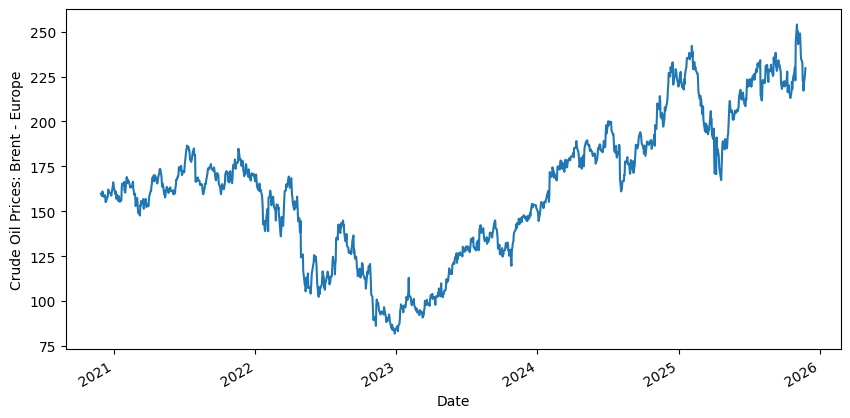

In [ ]:
# Setting the text on the Y-axis
plt.ylabel("Crude Oil Prices: Brent - Europe")

# Setting the size of our graph
data['Close'].plot(figsize=(10,5))

In [ ]:
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50']= data['Close'].shift(1).rolling(window=50).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

In [ ]:
data.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20
Date,,,,,,,,,,
2020-11-27 00:00:00-05:00,160.563004,160.809494,159.502502,159.766998,47858000,0.0,0.0,NaN,NaN,159.766998
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0,NaN,NaN,159.636998
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0,NaN,NaN,159.767188
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0,NaN,NaN,159.806170
2020-12-03 00:00:00-05:00,160.272995,161.432007,159.065506,159.336502,57840000,0.0,0.0,NaN,NaN,159.761440
2020-12-04 00:00:00-05:00,159.910507,159.910507,157.938004,158.128998,58272000,0.0,0.0,NaN,NaN,159.605969
2020-12-07 00:00:00-05:00,157.824005,159.037994,157.084503,157.899994,55026000,0.0,0.0,NaN,NaN,159.443495
2020-12-08 00:00:00-05:00,157.945007,159.206497,156.001007,158.864502,65726000,0.0,0.0,NaN,NaN,159.388353
2020-12-09 00:00:00-05:00,158.394501,158.721497,154.399994,155.210007,82016000,0.0,0.0,NaN,NaN,158.990415


In [ ]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-02-10 00:00:00-05:00,163.888376,160.86130
2021-02-11 00:00:00-05:00,163.813912,160.95254
2021-02-12 00:00:00-05:00,163.820730,161.04663
2021-02-16 00:00:00-05:00,163.785184,161.10426
2021-02-17 00:00:00-05:00,163.942024,161.16968


In [ ]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['SMA_20','EMA_20','SMA_50', 'Close']]

# Getting the head of the data
X.head()

,SMA_20,EMA_20,SMA_50,Close
Date,,,,
2021-02-10 00:00:00-05:00,162.862074,163.888376,160.86130,164.328995
2021-02-11 00:00:00-05:00,163.276449,163.813912,160.95254,163.106506
2021-02-12 00:00:00-05:00,163.517049,163.820730,161.04663,163.885498
2021-02-16 00:00:00-05:00,163.892649,163.785184,161.10426,163.447495
2021-02-17 00:00:00-05:00,164.304399,163.942024,161.16968,165.432007


In [ ]:
# Setting the training set to 80% of the data
training = 0.7
t = int(training*len(X))

# Training dataset
data_train= X[:t]

# Testing dataset
data_test = X[t:]

In [ ]:
from pycaret.regression import *
s = setup(
    data=data[['SMA_20','SMA_50','EMA_20','Close']],
    target='Close',
    session_id=123,
    numeric_features=['SMA_20','SMA_50','EMA_20'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1205, 4)"
4,Transformed data shape,"(1205, 4)"
5,Transformed train set shape,"(843, 4)"
6,Transformed test set shape,"(362, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,simple


In [ ]:
# Create a Linear Regression model
lr = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.7517,18.8340,4.3398,0.5837,0.0251,0.0217
1,1.9413,5.7817,2.4045,0.8078,0.0140,0.0114
2,4.5100,29.1069,5.3951,0.7298,0.0357,0.0301
3,3.7383,22.2589,4.7179,0.8581,0.0403,0.0322
4,3.4329,18.2759,4.2750,0.9163,0.0407,0.0325
5,1.5424,4.1402,2.0347,0.8924,0.0211,0.0162
6,1.4862,3.1980,1.7883,0.9753,0.0154,0.0127
7,3.0895,13.1191,3.6220,0.5783,0.0271,0.0232
8,1.9861,6.0399,2.4576,0.9415,0.0156,0.0127


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_lr = tune_model(lr)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.0360,7.3870,2.7179,0.8367,0.0154,0.0117
1,1.9332,5.8419,2.4170,0.8058,0.0140,0.0113
2,4.5034,28.4783,5.3365,0.7356,0.0353,0.0300
3,3.7410,22.2495,4.7169,0.8582,0.0402,0.0322
4,3.3967,18.0455,4.2480,0.9174,0.0404,0.0321
5,1.4981,3.7879,1.9463,0.9016,0.0201,0.0157
6,1.5056,3.2769,1.8102,0.9747,0.0155,0.0129
7,3.0996,13.1949,3.6325,0.5759,0.0272,0.0233
8,1.9815,5.9983,2.4491,0.9419,0.0155,0.0127


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


In [ ]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [ ]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,10.5508,151.9886,12.3284,-2.3598,0.0718,0.0598
1,4.6061,29.8547,5.4639,0.0073,0.0319,0.0274
2,10.9541,199.5272,14.1254,-0.8523,0.0942,0.0766
3,15.5815,291.2346,17.0656,-0.8563,0.1401,0.1368
4,9.3025,148.4127,12.1825,0.3207,0.1174,0.0948
5,6.1447,50.2719,7.0903,-0.3065,0.0739,0.0636
6,6.6037,73.7581,8.5883,0.4310,0.0786,0.0571
7,14.4679,260.7710,16.1484,-7.3816,0.1268,0.1071
8,5.7764,46.8452,6.8444,0.5460,0.0463,0.0379


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_rf = tune_model(rf)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.2626,123.5394,11.1148,-1.7309,0.0644,0.0524
1,4.2135,25.0298,5.0030,0.1678,0.0293,0.0251
2,10.6505,186.7563,13.6659,-0.7338,0.0915,0.0745
3,22.7034,662.6247,25.7415,-3.2236,0.2033,0.2023
4,10.4869,177.8850,13.3374,0.1858,0.1271,0.1063
5,5.9838,48.4629,6.9615,-0.2595,0.0725,0.0621
6,8.2210,97.9280,9.8959,0.2446,0.0925,0.0721
7,10.7265,150.2366,12.2571,-3.8288,0.0940,0.0790
8,11.3891,152.9773,12.3684,-0.4826,0.0847,0.0743


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
print(tuned_rf)

RandomForestRegressor(n_jobs=-1, random_state=123)


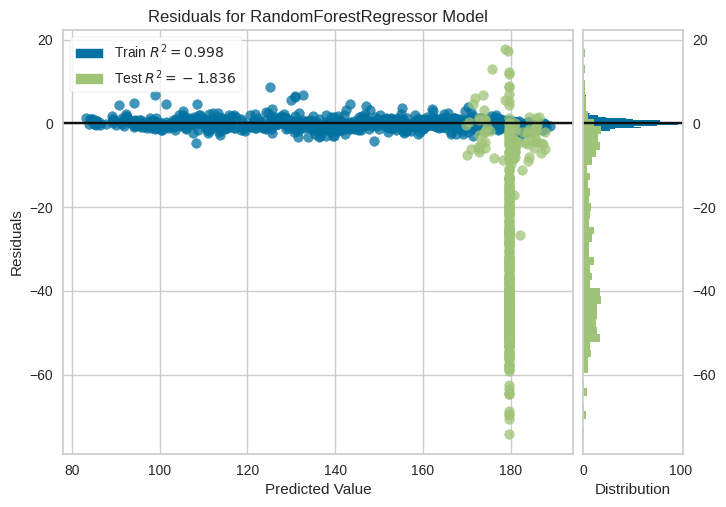

In [ ]:
plot_model(tuned_rf)

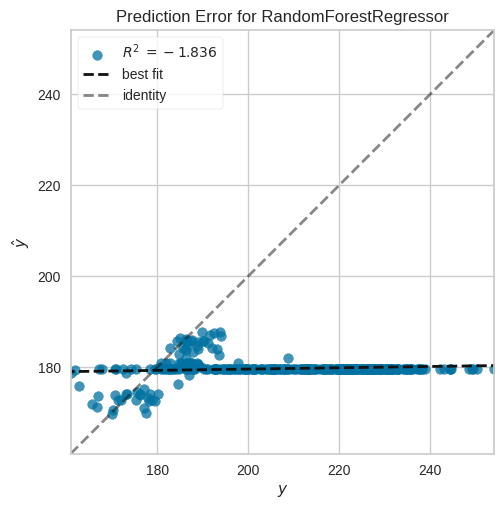

In [ ]:
plot_model(tuned_rf, plot = 'error')

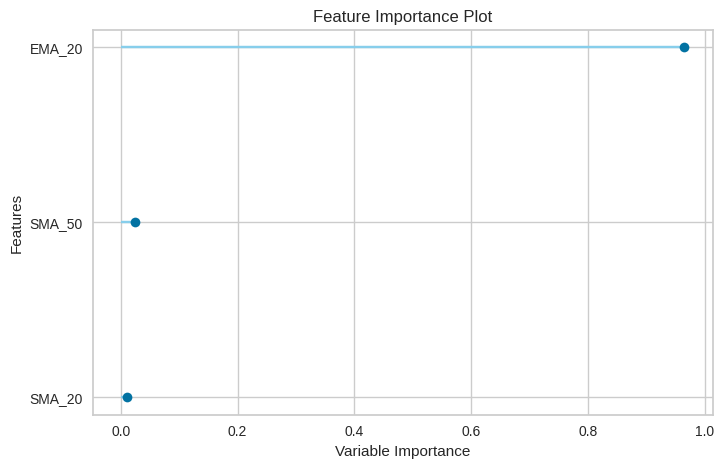

In [ ]:
plot_model(tuned_rf, plot = 'feature')

In [ ]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,28.7994,1202.3893,34.6755,-1.8356,0.1710,0.1309


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-06-18 00:00:00-04:00,182.626999,182.990799,183.461487,182.809998,184.278100
2024-06-20 00:00:00-04:00,182.590500,182.943207,183.712769,186.100006,184.023202
2024-06-21 00:00:00-04:00,182.738007,182.951797,184.223938,189.080002,184.057900
2024-06-24 00:00:00-04:00,183.035507,183.014404,184.352127,185.570007,184.317898
2024-06-25 00:00:00-04:00,183.261505,182.944794,184.541458,186.339996,183.842698
...,...,...,...,...,...
2025-11-19 00:00:00-05:00,236.360504,228.325607,234.090744,222.690002,179.673602
2025-11-20 00:00:00-05:00,236.597504,228.172806,232.476379,217.139999,179.673602
2025-11-21 00:00:00-05:00,236.399994,227.916595,231.353867,220.690002,179.673602


In [ ]:
final_rf = finalize_model(tuned_rf)

In [ ]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['SMA_20', 'SMA_50', 'EMA_20'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(n_jobs=-1, random_state=123))])


In [ ]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.1913,3.0044,1.7333,0.9929,0.0085,0.0058


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-06-18 00:00:00-04:00,182.626999,182.990799,183.461487,182.809998,183.582098
2024-06-20 00:00:00-04:00,182.590500,182.943207,183.712769,186.100006,185.461204
2024-06-21 00:00:00-04:00,182.738007,182.951797,184.223938,189.080002,187.669201
2024-06-24 00:00:00-04:00,183.035507,183.014404,184.352127,185.570007,185.995804
2024-06-25 00:00:00-04:00,183.261505,182.944794,184.541458,186.339996,185.953098
...,...,...,...,...,...
2025-11-19 00:00:00-05:00,236.360504,228.325607,234.090744,222.690002,224.054302
2025-11-20 00:00:00-05:00,236.597504,228.172806,232.476379,217.139999,219.347200
2025-11-21 00:00:00-05:00,236.399994,227.916595,231.353867,220.690002,222.231201


In [ ]:
unseenrf_predictions = predict_model(final_rf, data=data_test)
unseenrf_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.1913,3.0044,1.7333,0.9929,0.0085,0.0058


,SMA_20,EMA_20,SMA_50,Close,prediction_label
Date,,,,,
2024-06-18 00:00:00-04:00,182.626999,183.461487,182.990799,182.809998,183.582098
2024-06-20 00:00:00-04:00,182.590500,183.712769,182.943207,186.100006,185.461204
2024-06-21 00:00:00-04:00,182.738007,184.223938,182.951797,189.080002,187.669201
2024-06-24 00:00:00-04:00,183.035507,184.352127,183.014404,185.570007,185.995804
2024-06-25 00:00:00-04:00,183.261505,184.541458,182.944794,186.339996,185.953098
...,...,...,...,...,...
2025-11-19 00:00:00-05:00,236.360504,234.090744,228.325607,222.690002,224.054302
2025-11-20 00:00:00-05:00,236.597504,232.476379,228.172806,217.139999,219.347200
2025-11-21 00:00:00-05:00,236.399994,231.353867,227.916595,220.690002,222.231201


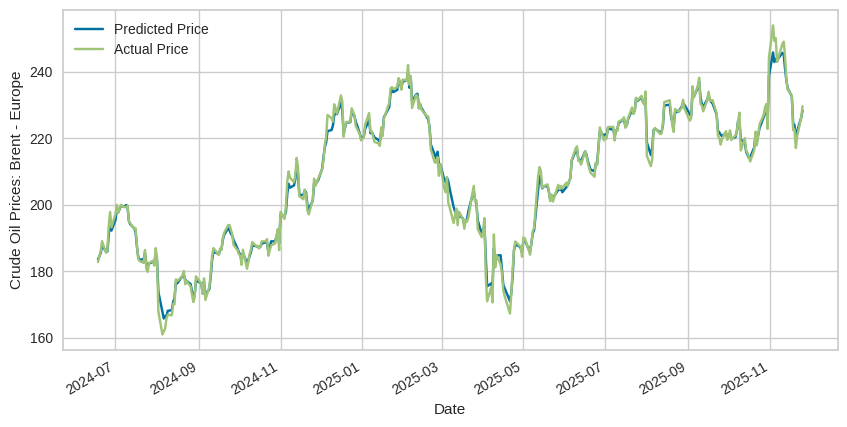

In [ ]:
predictedrf_price = pd.DataFrame(unseenrf_predictions,index=unseenrf_predictions.index,columns = ['prediction_label'])
predictedrf_price.plot(figsize=(10,5))
unseenrf_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Crude Oil Prices: Brent - Europe")
plt.show()